Model Coefficients:
 - Year_norm: -0.0533
 - conflict_flag: 0.7578
 - log_intensity: 1.4126
Intercept: 3.9165

Test Set Performance:
 - R²    : -0.077
 - RMSE  : 1.534
 - MAE   : 0.942


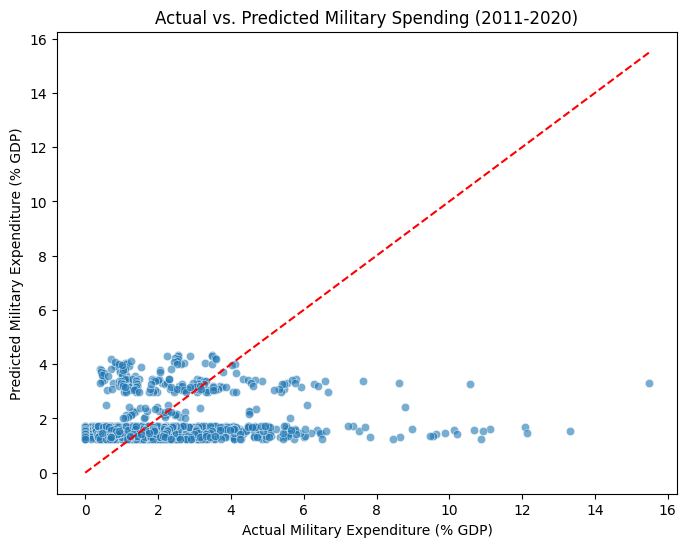

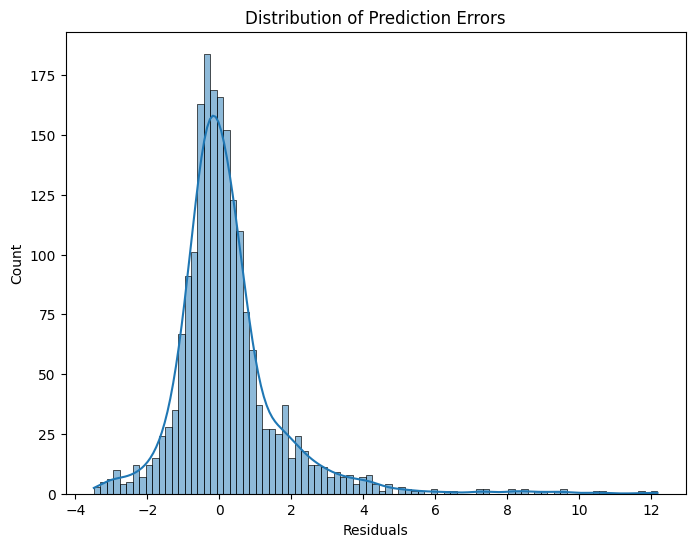

In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# Loading and preparing data from the datasets
mil = pd.read_csv('military expenditure.csv')
mil = mil.rename(columns={
    'country': 'Country',
    'year': 'Year',
    'Military expenditure (% of GDP)': 'military_expenditure'
})
mil = mil.dropna(subset=['military_expenditure'])

ucdp = pd.read_csv('UcdpPrioConflict_v24_1.csv', encoding='latin1')
ucdp['location_list'] = ucdp['location'].str.split(',')
ucdp_expanded = ucdp.explode('location_list')
ucdp_expanded['Country'] = ucdp_expanded['location_list'].str.strip()

conf_ctry_year = (
    ucdp_expanded
      .groupby(['Country','year'])
      .agg(conflict_count=('conflict_id','nunique'),
           total_intensity=('cumulative_intensity','sum'))
      .reset_index()
)
conf_ctry_year['conflict_flag'] = (conf_ctry_year['conflict_count'] > 0).astype(int)

# Merging the data
df = pd.merge(
    mil, conf_ctry_year,
    left_on=['Country','Year'],
    right_on=['Country','year'],
    how='left'
)
df['conflict_flag']   = df['conflict_flag'].fillna(0).astype(int)
df['total_intensity'] = df['total_intensity'].fillna(0)

# Feature engineering using Year (normalized), conflict_flag, and log-intensity as features
df['Year_norm'] = df['Year'] - df['Year'].min()
df['log_intensity'] = np.log1p(df['total_intensity'])

features = df[['Year_norm', 'conflict_flag', 'log_intensity']]
target = df['military_expenditure']

# Train-test split by year (training up to 2010 and testing after 2010)
train = df[df['Year'] <= 2010]
test  = df[df['Year'] >  2010]

X_train = train[['Year_norm', 'conflict_flag', 'log_intensity']]
y_train = train['military_expenditure']
X_test  = test[['Year_norm', 'conflict_flag', 'log_intensity']]
y_test  = test['military_expenditure']

# Fitting the linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

print(f"Model Coefficients:")
for name, coef in zip(X_train.columns, model.coef_):
    print(f" - {name}: {coef:.4f}")
print(f"Intercept: {model.intercept_:.4f}\n")

print(f"Test Set Performance:")
print(f" - R²    : {r2:.3f}")
print(f" - RMSE  : {rmse:.3f}")
print(f" - MAE   : {mae:.3f}")

# Visualization (actual vs predicted)
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Military Expenditure (% GDP)')
plt.ylabel('Predicted Military Expenditure (% GDP)')
plt.title('Actual vs. Predicted Military Spending (2011-2020)')
plt.show()

# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(8,6))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.title('Distribution of Prediction Errors')
plt.show()


## Interpretation of Linear Regression Results

### 1. Model Coefficients
- **Year_norm: –0.0533**  
  Every additional year since 1970 presents with a 0.053 percentage decrease in military expenditure as a share of GDP while holding conflict status and intensity as constant. In other words, across the sample, there’s a slight downward secular trend in spending when you control for wars.

- **conflict_flag: +0.7578**  
  Being in a conflict year, as compared to peacetime, shows an average 0.76 percentage‑point increase in military spending as % of GDP, all else equal. This matches the t‑test finding that conflict years tend to drive budgets up.

- **log_intensity: +1.4126**  
  A one‑unit increase in log1p(total_intensity) ( a close to 2.7× increase in battle‑death counts) corresponds to about a 1.41 percentage‑point increase in military spending while holding the other factors fixed. Higher‑casualty conflicts see larger budget spikes.

- **Intercept: 3.9165**  
  When Year_norm = 0 (i.e. in 1970), conflict_flag = 0 (peacetime), and intensity = 0, the model predicts a baseline spending of 3.92 % of GDP.

---

### 2. Model Performance on 2011–2020 Test Set
- **R² = –0.077**  
  A negative R² means the model’s predictions are worse, on average, compared to simply using the mean spending of the test set. This suggests the linear model is not capturing important drivers or non‑linearities in the post‑2010 data.

- **RMSE = 1.534**  
  The root mean squared error (RMSE) is 1.534 % of GDP. Hence on average, the predictions deviate from actual spending by around 1.5 percentage points.

- **MAE = 0.942**  
  The mean absolute error (MAE) is 0.942 % of GDP. Thus on average, the absolute prediction error is just under 1 percentage point.

---

### 3. What This Shows
- The sign and magnitude of the coefficients align with expectations that spending falls slowly over time but spikes during wars happen more so in intense conflicts.
- However, the poor out‑of‑sample fit (negative R²) indicates that:
  - **Year, conflict_flag, and intensity alone** are insufficient to predict future spending.
  - We’re likely missing **other predictors** (e.g., GDP growth, regime type, alliance membership) or need to model **non‑linear time trends** and country‑specific effects.
  
---




Random Forest Performance (2011-2020):
 R²   = 0.036
 RMSE = 1.451
 MAE  = 0.937


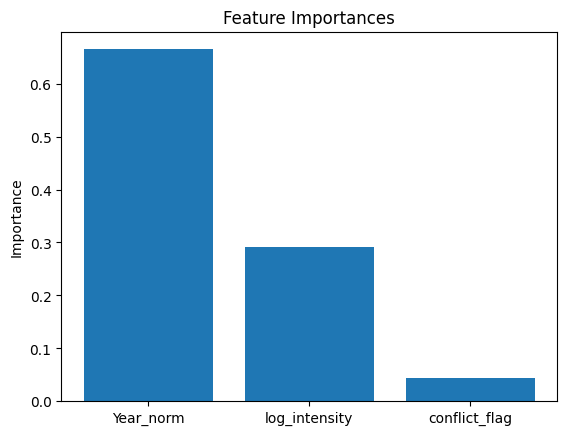

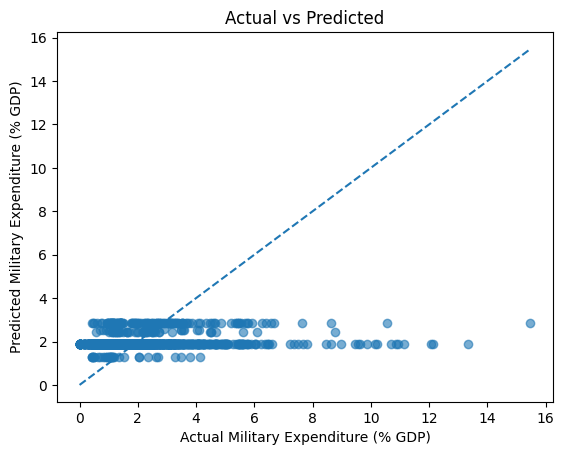

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# 1. Load and prepare data (using absolute paths)
mil = pd.read_csv('military expenditure.csv')
mil = mil.rename(columns={
    'country': 'Country',
    'year': 'Year',
    'Military expenditure (% of GDP)': 'military_expenditure'
})
mil = mil.dropna(subset=['military_expenditure'])

ucdp = pd.read_csv('UcdpPrioConflict_v24_1.csv', encoding='latin1')
ucdp['location_list'] = ucdp['location'].str.split(',')
ucdp_expanded = ucdp.explode('location_list')
ucdp_expanded['Country'] = ucdp_expanded['location_list'].str.strip()

conf_ctry_year = (
    ucdp_expanded
      .groupby(['Country','year'])
      .agg(conflict_count=('conflict_id','nunique'),
           total_intensity=('cumulative_intensity','sum'))
      .reset_index()
)
conf_ctry_year['conflict_flag'] = (conf_ctry_year['conflict_count'] > 0).astype(int)

# Merge
df = pd.merge(
    mil, conf_ctry_year,
    left_on=['Country','Year'],
    right_on=['Country','year'],
    how='left'
)
df['conflict_flag']   = df['conflict_flag'].fillna(0).astype(int)
df['total_intensity'] = df['total_intensity'].fillna(0)

# 2. Feature engineering
df['Year_norm'] = df['Year'] - df['Year'].min()
df['log_intensity'] = np.log1p(df['total_intensity'])

features = ['Year_norm', 'conflict_flag', 'log_intensity']
X_train = df[df['Year'] <= 2010][features]
y_train = df[df['Year'] <= 2010]['military_expenditure']
X_test  = df[df['Year'] > 2010][features]
y_test  = df[df['Year'] > 2010]['military_expenditure']

# 3. Fit Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# 4. Evaluation metrics
r2_rf   = r2_score(y_test, y_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred))
mae_rf  = mean_absolute_error(y_test, y_pred)

print("Random Forest Performance (2011-2020):")
print(f" R²   = {r2_rf:.3f}")
print(f" RMSE = {rmse_rf:.3f}")
print(f" MAE  = {mae_rf:.3f}")

# 5. Feature Importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.bar(range(len(features)), importances[indices])
plt.xticks(range(len(features)), [features[i] for i in indices])
plt.ylabel('Importance')
plt.title('Feature Importances')
plt.show()

# 6. Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.6)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], '--')
plt.xlabel('Actual Military Expenditure (% GDP)')
plt.ylabel('Predicted Military Expenditure (% GDP)')
plt.title('Actual vs Predicted')
plt.show()


## Interpretation of Random Forest Results

**Performance Metrics (2011–2020 Test Set)**  
- **R² = 0.036**  
  - The model explains only 3.6% of the variance in countries military expenditure.  
  - This low R² reflects that, while the predictors capture some signal, the bulk of the variation (96.4%) remains unexplained by these three features alone.

- **RMSE = 1.451**  
  - The root mean squared error (RMSE) of 1.451 % GDP means that, on average, predictions are about 1.45 percentage points off from the true values.  
  - Because military spending ranges roughly from 0 % to 16 % of GDP, an error of nearly 1.5 points is moderate but still somewhat significant relative to the lower end of the scale.

- **MAE = 0.937**  
  - The mean absolute error (MSE) of 0.937 % GDP tells us that, on average, the model’s predictions miss the actual value by just under 1 percentage point.  
  - MAE is less sensitive to outliers than RMSE, so this number indicates typical prediction error.

---

### What These Numbers Tell Us

1. **Limited Predictive Power**  
   - An R² near zero shows that year, conflict_flag, and conflict intensity alone are not enough to predict military spending accurately across all countries.  
   - Many other factors such as economic, political, demographic and strategic also likely drive defense budgets.

2. **Error Magnitude**  
   - The MAE (0.937) is almost the exact same as our linear model’s MAE (0.942), suggesting that Random Forest did not dramatically improve absolute forecast accuracy with the same features.  
   - RMSE  > MAE highlights that larger errors such as underpredicting big military spenders inflate the squared-error metric.

3. **Underprediction of Extremes**  
   - Because RF averages many trees, it tends to regress toward the mean, underestimating very high spending countries or years and overestimating the very low ones.

---
